In [1]:
import sys
import os
sys.path.append('/project/GCRB/Hon_lab/s223695/Data_project/Perturb_seq_shared/')

import pandas as pd
import numpy as np
import scanpy as sc

from sklearn.cluster import KMeans
import scipy.stats
from itertools import combinations
from sklearn.metrics import pairwise_distances

import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'axes.labelsize' : 'large',
                     'pdf.fonttype':42
                    }) 
from matplotlib.backends.backend_pdf import PdfPages

from tqdm import tqdm
from tqdm.contrib.concurrent import process_map

import gc
import warnings
import time
import pickle
import json
import warnings
warnings.simplefilter("ignore")

from sklearn.metrics import pairwise_distances
from multiprocessing import Pool
import torch

from importlib import reload
import util_functions

/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
valid_chr_list = ['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14',
                  'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr20',
                  'chr21', 'chr22', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8',
                  'chr9', 'chrX', 'chrY']

In [3]:
table_file_name = "/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20240219_WTC11_TFPerturb_CM-full_all/pySpade/TFPerturb_global_v1.csv"
annotate_file_name = "/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20240219_WTC11_TFPerturb_CM-full_all/pySpade/annotation_dict_hg38.txt"

In [4]:
table_df = pd.read_csv(table_file_name,index_col=0)

In [5]:
annotate_df = pd.read_csv(annotate_file_name,index_col=0,sep="\t",header=None,
                          names=["gene_name"]
                         )

In [6]:
annotate_df

,gene_name
chr11:5301689-5301949,OR51B4
chr19:51887666-51887940,ZNF577
chrX:72276872-72277245,RPS4X
chr19:20167219-20167664,ZNF486
chr3:149086130-149086516,HLTF
...,...
chr8:7385057-7386057,ZNF705G
chr4:160411-161411,ZNF718
chr4:160581-161581,ZNF718
chr19:23002645-23003645,ZNF728


In [7]:
table_df["region_chr"] = table_df.loc[:,"region"].apply(lambda x: x.split(":")[0])
table_df = table_df[table_df["region_chr"].isin(valid_chr_list)]
table_df["region_center"] = table_df.loc[:,"region"].apply(lambda x: round((int(x.split(":")[1].split("-")[0]) + 
                                                                            int(x.split(":")[1].split("-")[1]))/2
                                                                          ))
table_df["region_name"] = table_df.loc[:,"region"].apply(lambda x: annotate_df.at[x,"gene_name"])

In [8]:
table_df["pos_diff"] = np.abs(table_df["pos"] - table_df["region_center"])

In [9]:
region_list = np.unique(table_df["region"])

In [10]:
region_list[0]

'chr10:100745594-100746092'

In [11]:
table_samechr = table_df[table_df["region_chr"] == table_df["chromosome"]]
for region_tmp in region_list[:4]:
    table_ext = table_samechr[table_samechr["region"] == region_tmp]
    

In [12]:
table_df_kd = table_df[table_df["gene_names"]==table_df["region_name"]]
table_df_kd["cpm_bg_log10"] = np.log10(table_df_kd["cpm_bg"]+1)
table_df_kd["cpm_perturb_log10"] = np.log10(table_df_kd["cpm_perturb"]+1)

In [13]:
table_df_kd.head()

,idx,gene_names,chromosome,pos,strand,color_idx,chr_idx,region,num_cell,bin,...,fc_by_rand_dist_cpm,pval-empirical,cpm_perturb,cpm_bg,region_chr,region_center,region_name,pos_diff,cpm_bg_log10,cpm_perturb_log10
843,5634,NCOA1,chr2,273448336,+,1,1,chr2:24491867-24491918,1095,1000,...,0.475884,0.000,36.466845,76.640684,chr2,24491892,NCOA1,248956444,1.890089,1.573647
17514,17564,ZFP2,chr5,1058555959,+,0,4,chr5:178895913-178896082,908,1000,...,0.517057,0.027,3.533763,6.843724,chr5,178895998,ZFP2,879659961,0.894522,0.656459
32906,19460,BACH2,chr6,1151495232,-,1,5,chr6:90296557-90296779,956,1000,...,0.358575,0.000,22.342504,62.327077,chr6,90296668,BACH2,1061198564,1.801589,1.368147
48426,24629,MYBL1,chr8,1457964523,-,1,7,chr8:66612966-66613289,976,1000,...,0.902897,0.290,1.126639,1.248881,chr8,66613128,MYBL1,1391351395,0.351966,0.327694
78467,24262,ZMAT4,chr8,1432248109,-,1,7,chr8:40897731-40897823,999,1000,...,0.220168,0.000,2.794273,12.726978,chr8,40897777,ZMAT4,1391350332,1.137575,0.579129


In [14]:
table_df_kd

,idx,gene_names,chromosome,pos,strand,color_idx,chr_idx,region,num_cell,bin,...,fc_by_rand_dist_cpm,pval-empirical,cpm_perturb,cpm_bg,region_chr,region_center,region_name,pos_diff,cpm_bg_log10,cpm_perturb_log10
843,5634,NCOA1,chr2,273448336,+,1,1,chr2:24491867-24491918,1095,1000,...,0.475884,0.000,36.466845,76.640684,chr2,24491892,NCOA1,248956444,1.890089,1.573647
17514,17564,ZFP2,chr5,1058555959,+,0,4,chr5:178895913-178896082,908,1000,...,0.517057,0.027,3.533763,6.843724,chr5,178895998,ZFP2,879659961,0.894522,0.656459
32906,19460,BACH2,chr6,1151495232,-,1,5,chr6:90296557-90296779,956,1000,...,0.358575,0.000,22.342504,62.327077,chr6,90296668,BACH2,1061198564,1.801589,1.368147
48426,24629,MYBL1,chr8,1457964523,-,1,7,chr8:66612966-66613289,976,1000,...,0.902897,0.290,1.126639,1.248881,chr8,66613128,MYBL1,1391351395,0.351966,0.327694
78467,24262,ZMAT4,chr8,1432248109,-,1,7,chr8:40897731-40897823,999,1000,...,0.220168,0.000,2.794273,12.726978,chr8,40897777,ZMAT4,1391350332,1.137575,0.579129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31436939,24397,SNAI2,chr8,1440272016,-,1,7,chr8:48921305-48921393,840,750,...,0.136012,0.000,4.820511,35.505316,chr8,48921349,SNAI2,1391350667,1.562356,0.764961
31484880,51741,ZNF550,chr19,2711971151,-,0,18,chr19:57559735-57559886,848,750,...,0.208290,0.000,3.682893,17.719601,chr19,57559810,ZNF550,2654411341,1.272297,0.670514
31499600,50804,ZNF283,chr19,2698238580,+,0,18,chr19:43827376-43827637,856,750,...,0.132553,0.000,1.898889,14.390910,chr19,43827506,ZNF283,2654411074,1.187264,0.462232
31574089,56085,TFE3,chrX,2924045008,-,0,22,chrX:49042845-49043845,794,750,...,0.613045,0.006,6.901803,11.264540,chrX,49043345,TFE3,2875001663,1.088651,0.897726


In [15]:
np.sum(table_df_kd["fc"]<1)

1402

In [16]:
np.sum(table_df_kd["fc"]<0.5)

1027

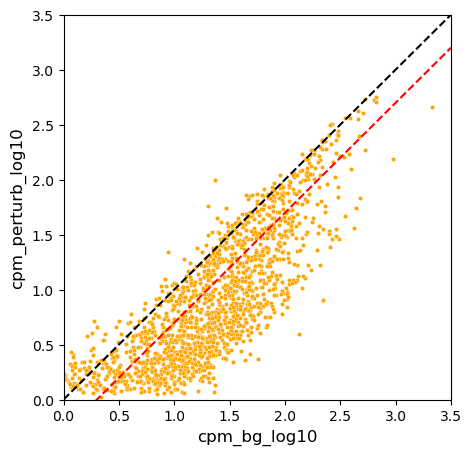

In [17]:
max_value = 3.5
plt.subplots(figsize=(5,5))
plt.xlim(0,max_value)
plt.ylim(0,max_value)
plt.plot((0,max_value),(0,max_value),color="black",linestyle="--")
plt.plot((0,max_value),(-0.301,max_value-0.301),color="red",linestyle="--")
sns.scatterplot(x=table_df_kd["cpm_bg_log10"],
                y=table_df_kd["cpm_perturb_log10"],s=10,
                color="orange"
           )
plt.savefig("kd_efficiency.pdf")

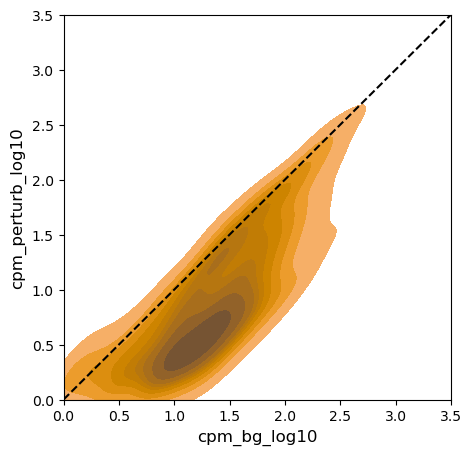

In [18]:
max_value = 3.5
plt.subplots(figsize=(5,5))
plt.xlim(0,max_value)
plt.ylim(0,max_value)
plt.plot((0,max_value),(0,max_value),color="black",linestyle="--")
#plt.plot((0,max_value),(-0.301,max_value-0.301),color="red",linestyle="--")
sns.kdeplot(x=table_df_kd["cpm_bg_log10"],
                y=table_df_kd["cpm_perturb_log10"],s=10,
                color="orange",fill=True
           )
plt.savefig("kd_efficiency_kde.pdf")

<h3>calculate from raw data</h3>

In [19]:
json_fp = "./config.json"
with open(json_fp, 'r') as fp:
    config = json.load(fp)
    input_file = config["input_data"]["input_file"]
    
sgRNA_file = config["input_data"]["sgRNA_file"]

gRNA_dict_file = config["user_defined_data"]["gRNA_dict_file"]
pca_file = config["user_defined_data"]["pca_file"]
annotation_file = config["user_defined_data"]["annotation_file"]


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

(X,gRNA_dict) = util_functions.load_files(input_file,sgRNA_file,gRNA_dict_file,pca_file)

read input
read pickle
read from dictionary


In [20]:
sgRNA_clear_df = pd.read_csv("/project/GCRB/Hon_lab/s223695/Data_project/TFperturb_edist_052924/sgRNA_outlier_dist_clear_v3.csv",
                             index_col=0
                            )

In [21]:
sgRNA_clear_df.head()

,pval_outlier
ADNP2_-_77867536.23-P1P2-1,1.0
ADNP2_-_77867536.23-P1P2-2,1.0
ADNP2_-_77867648.23-P1P2-2,1.0
AEBP1_+_44143999.23-P1P2-1,1.0
AEBP1_+_44143999.23-P1P2-2,1.0


In [22]:
nontarget_clear_df = pd.read_csv("/project/GCRB/Hon_lab/s223695/Data_project/TFperturb_edist_052924/non_targeting_background_full_v3.csv",
                                 index_col=0
                                )

In [23]:
nontarget_clear_list = np.unique(np.concatenate(nontarget_clear_df.values))

In [24]:
np.random.seed(1234)
nontarget_clear_list_pick = np.random.choice(nontarget_clear_list,10000,replace=False)

In [25]:
input_ad = sc.read_h5ad(input_file)

In [26]:
annotation_file = "full_annotation_df.csv"
annotation_df = pd.read_csv(annotation_file,index_col=0)
annotation_df.head()

,guide_chr,guide_start,guide_end,protospacer_target,intended_target_region,transcript_target,source,closest_gene,closest_dist
0,chr17,36948966,36948966,AATF_-_35306286.23-P1P2-1,chr17:36948966-36949088,AATF:P1P2,TF,AATF,8
1,chr17,36949026,36949026,AATF_-_35306286.23-P1P2-2,chr17:36948966-36949088,AATF:P1P2,TF,AATF,8
2,chr17,36949013,36949013,AATF_-_35306333.23-P1P2-1,chr17:36948966-36949088,AATF:P1P2,TF,AATF,8
3,chr17,36949070,36949070,AATF_-_35306333.23-P1P2-2,chr17:36948966-36949088,AATF:P1P2,TF,AATF,8
4,chr17,36949031,36949031,AATF_-_35306351.23-P1P2-1,chr17:36948966-36949088,AATF:P1P2,TF,AATF,8


In [27]:
gRNA_gene_dict = {}
for target_gene in np.unique(annotation_df["closest_gene"]):
    target_gRNAs = np.unique(annotation_df[annotation_df["closest_gene"]==target_gene]["protospacer_target"])
    target_gRNAs = target_gRNAs[np.isin(target_gRNAs,sgRNA_clear_df.index)]
    if target_gRNAs.shape[0]==0:
        print(target_gene)
        continue
    gRNA_gene_dict[target_gene] = target_gRNAs.tolist()

AATF
AC118549.1
ADNP
AEBP2
AK6
ARID3C
ATF5
BDP1
BRIP1
CARF
CBFA2T2
CBFB
CDC5L
CDK1
CDK7
CEBPZ
CENPA
CENPT
CHMP2A
CIR1
CREM
CRTC3
CTCF
CTNNB1
CXXC1
DMAP1
DNAJC2
DNAJC21
DNMT1
DR1
E4F1
EBF4
ELOC
ELP3
ENO1
EP400
ERCC2
ERCC3
ETF1
FOXH1
FOXK2
FUBP1
FXN
GABPB1
GART
GMEB1
GMEB2
GTF2A2
GTF2B
GTF2E1
GTF2F1
GTF2F2
GTF2H1
GTF2H3
GTF3C3
HDAC3
HDGF
HES1
HINFP
HIRA
HNRNPK
HNRNPU
IGHMBP2
ILF2
ILF3
IRX6
KAT2A
KIN
KLF16
LCOR
LIN9
LRPPRC
MARS
MAX
MBD3
MED8
MIS18BP1
MNAT1
MSANTD3
MSLN
MTA1
MTERF3
MYBBP1A
MYBL2
MYSM1
NCOA3
NELFE
NFATC3
NFE4
NFKB1
NFRKB
NFYC
NHP2
NOC3L
NRF1
NSD2
PAXBP1
PBRM1
PFDN5
PHB2
PHF20
PINX1
PLEKHA5
POLR3C
POLR3K
PPIL4
PPP1CB
PRDM10
PRDM14
PSMA1
PSMB1
PTTG1
PUF60
PURG
RBSN
RELB
RNF4
RPA3
RPF1
RPS4X
RUVBL1
SACM1L
SAFB
SALL4
SCRT1
SETD1A
SLC30A9
SLC39A7
SMARCA5
SMARCC1
SMARCC2
SNAPC1
SNAPC2
SNAPC3
SOX18
SP2
SRCAP
SSRP1
STRAP
SUPT5H
SUZ12
TADA2A
TAF1
TAF11
TAF13
TAF1A
TAF1B
TAF7
TAZ
TBP
TCERG1
TEAD3
TERF2
TFAM
TFDP1
TSHZ2
VPS72
WDHD1
XRCC5
XRCC6
ZBTB33
ZBTB44
ZC3H8
ZNF142
ZNF143
ZNF281


In [28]:
len(gRNA_gene_dict.keys())

1781

In [29]:
target_gene_list = np.unique(list(gRNA_gene_dict.keys()))

In [30]:
target_gene_list

array(['AC010255.3', 'AC022506.1', 'ADNP2', ..., 'ZXDA', 'ZXDB', 'ZXDC'],
      dtype='<U10')

In [31]:
target_gene_list_clear = target_gene_list[np.isin(target_gene_list,input_ad.var.index)]

In [32]:
print(target_gene_list.shape)
print(target_gene_list_clear.shape)

(1781,)
(1758,)


In [33]:
gene_index = []
for targe_gene in tqdm(target_gene_list_clear):
    gene_index += np.where(input_ad.var.index==targe_gene)

gene_index = np.concatenate(gene_index)

100%|██████████| 1758/1758 [00:02<00:00, 592.88it/s]


In [34]:
total_sum = np.sum(np.exp(input_ad.raw.X[1,:].toarray())-1)

In [35]:
exp_arr = input_ad.raw.X[:,gene_index].toarray()
exp_arr = np.exp(exp_arr)-1
exp_arr = exp_arr/total_sum*1000000 #calculate TPM

In [36]:
exp_df = pd.DataFrame(exp_arr,index=input_ad.obs.index,columns=target_gene_list_clear)

In [37]:
exp_df.head()

,AC010255.3,ADNP2,AEBP1,AFF1,AFF2,AFF3,AFF4,AHCTF1,AHCY,AHDC1,...,ZSCAN30,ZSCAN31,ZSCAN32,ZSCAN5A,ZSCAN5B,ZSCAN9,ZUP1,ZXDA,ZXDB,ZXDC
AAACCTGAGAAACCGC-1,0.0,0.0,355.871802,355.871802,0.0,0.000000,355.871802,0.00000,0.000000,0.0,...,0.0,0.0,0.000000,355.871802,0.0,0.00000,0.000000,0.0,0.0,0.0
AAACCTGAGAAACGCC-19,0.0,0.0,0.000000,300.751912,0.0,0.000000,300.751912,0.00000,300.751912,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0
AAACCTGAGAAAGTGG-17,0.0,0.0,352.858071,0.000000,0.0,352.858071,705.716142,0.00000,0.000000,0.0,...,0.0,0.0,352.858071,0.000000,0.0,0.00000,352.858071,0.0,0.0,0.0
AAACCTGAGAAAGTGG-24,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.00000,0.000000,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.00000,0.000000,0.0,0.0,0.0
AAACCTGAGAACAATC-15,0.0,0.0,339.673890,0.000000,0.0,0.000000,679.347664,339.67389,0.000000,0.0,...,0.0,0.0,0.000000,0.000000,0.0,339.67389,0.000000,0.0,0.0,0.0


In [38]:
res_arr = []
for target_gene in tqdm(target_gene_list_clear):
    target_gRNAs = gRNA_gene_dict[target_gene]
    target_cells = np.unique(np.concatenate([gRNA_dict[x] for x in target_gRNAs]))
    target_cell_expression = np.mean(exp_df.loc[target_cells,target_gene])
    nontarget_cell_expression = np.mean(exp_df.loc[nontarget_clear_list_pick,target_gene])
    res_arr += [[target_gene,nontarget_cell_expression,target_cell_expression]]

100%|██████████| 1758/1758 [00:09<00:00, 178.63it/s]


In [39]:
res_df = pd.DataFrame(res_arr,columns=["target_gene","non_target","target"])

In [40]:
res_df["non_target_log"] = np.log10(res_df["non_target"]+1)
res_df["target_log"] = np.log10(res_df["target"]+1)

In [52]:
res_df_exp = res_df[res_df["non_target_log"]>0.5]

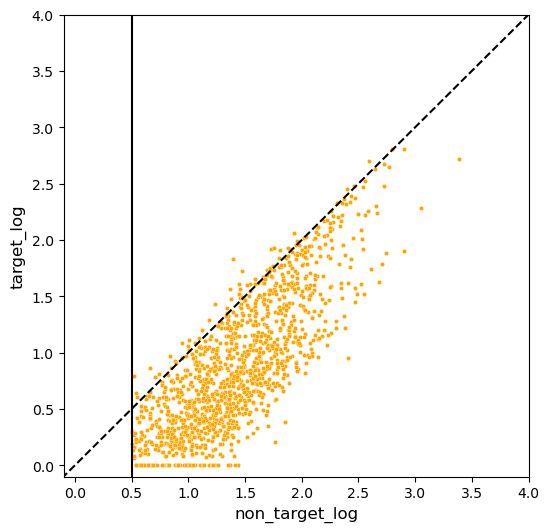

In [56]:
fig,ax = plt.subplots(figsize=(6,6))
sns.scatterplot(data=res_df_exp,x="non_target_log",y="target_log",color="orange",s=10)
ax.axvline(x=0.5,color="black")
ax.set_xlim(-0.1,4)
ax.set_ylim(-0.1,4)
ax.plot([-1,4],[-1,4],color="black",linestyle="--")
plt.savefig("./figures/kd_efficiency_scatter.pdf")

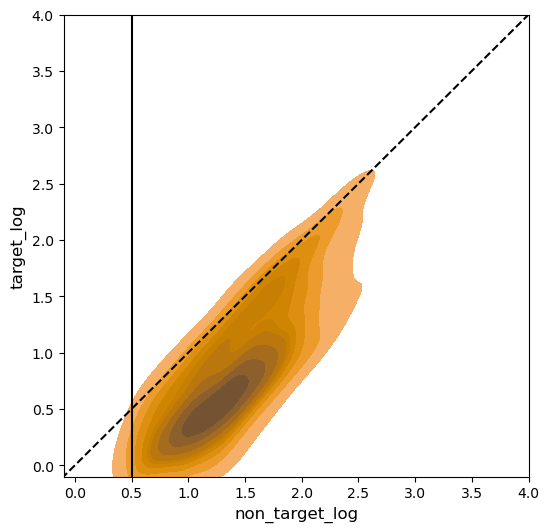

In [57]:
fig,ax = plt.subplots(figsize=(6,6))
sns.kdeplot(data=res_df_exp,x="non_target_log",y="target_log",color="orange",fill=True)
ax.axvline(x=0.5,color="black")
ax.set_xlim(-0.1,4)
ax.set_ylim(-0.1,4)
ax.plot([-1,4],[-1,4],color="black",linestyle="--")
plt.savefig("./figures/kd_efficiency_kde.pdf")

In [43]:
res_df[res_df["target_gene"]=="HOXB4"]

,target_gene,non_target,target,non_target_log,target_log
444,HOXB4,68.692103,5.490927,1.843184,0.812307


In [71]:
filtered_num_df = pd.DataFrame(
                    [[1899,966,755,450,363,223],
                     [97,36,28,10,6,3]],
                    columns=["1.0","0.1","0.05","0.01","0.005","0.001"],
                    index=["TF","OR_gene"]).T

In [82]:
filtered_num_df["enrichment"] = filtered_num_df["OR_gene"]/filtered_num_df["TF"]*100

In [83]:
filtered_num_df

,TF,OR_gene,enrichment
1.0,1899,97,5.107952
0.1,966,36,3.726708
0.05,755,28,3.708609
0.01,450,10,2.222222
0.005,363,6,1.652893
0.001,223,3,1.345291


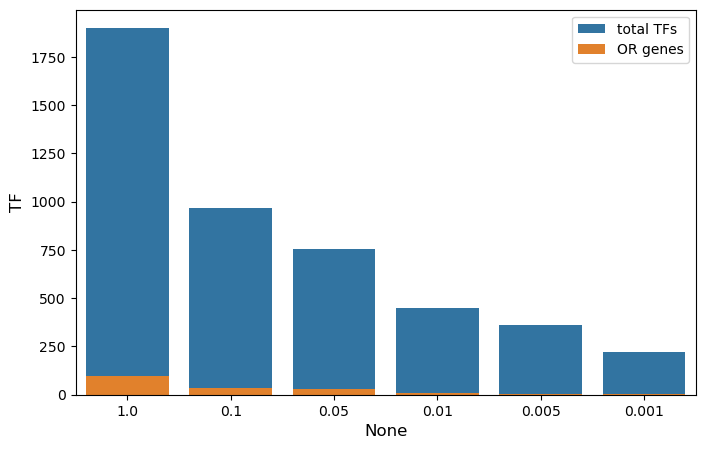

In [88]:
fig,ax=plt.subplots(figsize=(8,5))
sns.barplot(data=filtered_num_df,y="TF",x=filtered_num_df.index,ax=ax,label="total TFs")
sns.barplot(data=filtered_num_df,y="OR_gene",x=filtered_num_df.index,ax=ax,label="OR genes")
plt.savefig("./figures/pval_cut_off_bar.pdf")

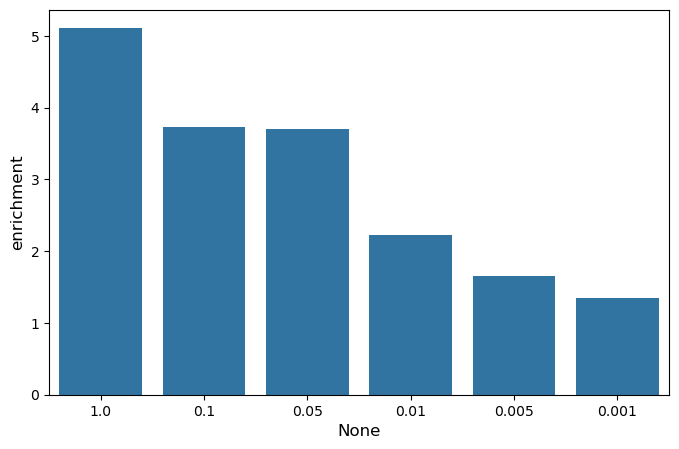

In [89]:
fig,ax=plt.subplots(figsize=(8,5))
sns.barplot(data=filtered_num_df,y="enrichment",x=filtered_num_df.index)
plt.savefig("./figures/pval_cut_off_enrich.pdf")